# 02 · What the model reads

*Schemas, catalogs and chat templates: how `pcd` turns a set of fields into the one prompt every decision is read from, and why that prompt lists every allowed value.*

> **TL;DR**
> - A schema is a closed set of decisions: every field is a boolean or an enum. A preset dict, a JSON Schema and a Pydantic model compile to the same schema, down to its fingerprint. Free text is rejected up front.
> - `pcd` never hand-writes a chat format. It renders the conversation through the model's own chat template with a marker where the input goes, then splits the result into a static **head**, the per-request **context** and a static **tail** that already opens the JSON object.
> - Templates have opinions: Gemma 2 refuses a system turn, Qwen3 thinks unless told not to, Llama 3.2 writes today's date into the prompt. The renderer adapts to each, and we measure what goes wrong when it doesn't.
> - Listing every allowed value is not optional. Without the list, the median candidate mass of the triage schema's enum fields falls from 0.98 to 0.03, and the "probabilities" become renormalized noise. The list doubles the head, but the head is identical for every request, so its prefill is paid once.

We use the same model as post [01](01_why_parallel_decoding.ipynb), Qwen2.5-1.5B-Instruct in 4-bit on MLX, and the same `support_triage` ticket. Sections 1 to 3 only need tokenizers; section 4 briefly runs Qwen3-0.6B, and sections 5 and 6 run Qwen2.5.

In [1]:
from nbutils import *
from enum import Enum
from typing import Literal
import numpy as np
import matplotlib.pyplot as plt
from pydantic import BaseModel, Field as PField
from transformers import AutoTokenizer

from pcd import Engine, PromptFormat, Schema, SchemaError
from pcd.backends.base import Query
from pcd.compiler import compile_schema, encode_after
from pcd.prompt import FAMILY_DEFAULTS, build_prompt
from pcd.schema import render_label
from pcd.tokenizer import HFTokenizer


environment()
engine = Engine(load())          # qwen2.5-1.5b, 4-bit MLX
tok = engine.tokenizer
preset = load_preset("support_triage")
ticket, triage = preset["context"], preset["schema"]

Apple M1 Pro, 16 GB | macOS 15.1.1 | Python 3.13.5 | pcd 0.1.0, mlx 0.32.2, mlx-lm 0.31.3, torch 2.14.0, transformers 5.17.0


## 1. A schema is a closed set of decisions

Parallel decoding only works if every value a field can take is known before the model runs: the decoder scores a fixed list of candidates, it never generates. So a `pcd` schema has exactly two kinds of field, `boolean` and `enum`, and an enum's choices may be strings or numbers.

People describe schemas in different ways, so `Schema` accepts three. Here is the same three-field schema written as a preset-style dict, as a JSON Schema, and as a Pydantic model:

In [2]:
spec = {
    "sentiment": {"type": "enum", "choices": ["POSITIVE", "NEUTRAL", "NEGATIVE"], "description": "Customer mood"},
    "wants_refund": {"type": "boolean", "description": "Whether the customer asks for money back"},
    "priority": {"type": "enum", "choices": [1, 2, 3], "description": "Priority, 1 is highest"},
}

json_schema = {"type": "object", "properties": {
    "sentiment": {"enum": ["POSITIVE", "NEUTRAL", "NEGATIVE"], "description": "Customer mood"},
    "wants_refund": {"type": "boolean", "description": "Whether the customer asks for money back"},
    "priority": {"enum": [1, 2, 3], "description": "Priority, 1 is highest"},
}}

class Mood(str, Enum):
    POSITIVE = "POSITIVE"
    NEUTRAL = "NEUTRAL"
    NEGATIVE = "NEGATIVE"

class Ticket(BaseModel):
    sentiment: Mood = PField(description="Customer mood")
    wants_refund: bool = PField(description="Whether the customer asks for money back")
    priority: Literal[1, 2, 3] = PField(description="Priority, 1 is highest")

small = Schema.from_dict(spec)
for source, s in [("preset dict", small), ("JSON Schema", Schema.from_json_schema(json_schema)),
                  ("Pydantic", Schema.from_pydantic(Ticket))]:
    print(f"{source:12} {s!r:28} fingerprint {s.fingerprint}")

preset dict  Schema(3 fields, 1 wave(s))  fingerprint 062e0d2d52d88430
JSON Schema  Schema(3 fields, 1 wave(s))  fingerprint 062e0d2d52d88430
Pydantic     Schema(3 fields, 1 wave(s))  fingerprint 062e0d2d52d88430


Pydantic does not emit the enum inline: it writes `{"$ref": "#/$defs/Mood"}` and a `Literal` becomes an `enum` with `"type": "integer"`. `from_json_schema` resolves references, `const`/`anyOf` unions and single-element `allOf`, then normalizes everything into the same `Field` objects. The fingerprint is a hash of that normalized form, and `Engine` uses it as the key of its compile cache, so the three spellings share one compiled schema.

Each field knows its labels and how each label is written in JSON (`render_label`). The decoder will compare exactly these strings:

In [3]:
for f in small:
    print(f"{f.name:13} {f.type:8} labels {f.labels!r:34} written as {' | '.join(render_label(l) for l in f.labels)}")

sentiment     enum     labels ('POSITIVE', 'NEUTRAL', 'NEGATIVE') written as "POSITIVE" | "NEUTRAL" | "NEGATIVE"
wants_refund  boolean  labels (True, False)                      written as true | false
priority      enum     labels (1, 2, 3)                          written as 1 | 2 | 3


Anything without a closed set of values is refused when the schema is built, not halfway through a request:

In [4]:
for prop in [{"type": "string", "description": "One-line summary"}, {"type": "number", "minimum": 0}]:
    try:
        Schema.from_json_schema({"properties": {"x": prop}})
    except SchemaError as e:
        print(f"{prop}\n  -> SchemaError: {e}\n")

{'type': 'string', 'description': 'One-line summary'}
  -> SchemaError: property 'x' is neither a boolean nor an enum; parallel constrained decoding needs a closed set of values

{'type': 'number', 'minimum': 0}
  -> SchemaError: property 'x' is neither a boolean nor an enum; parallel constrained decoding needs a closed set of values



Fields can also declare `depends_on`. This is the schema from `examples/quickstart.py`, where the routing team depends on the topic:

In [5]:
quick = Schema.from_dict({
    "sentiment": {"type": "enum", "choices": ["POSITIVE", "NEUTRAL", "NEGATIVE"]},
    "topic": {"type": "enum", "choices": ["BILLING", "TECHNICAL_ISSUE", "ACCOUNT_ACCESS"]},
    "wants_refund": {"type": "boolean"},
    "deadline": {"type": "enum", "choices": ["1_HOUR", "12_HOURS", "1_WEEK", "NONE"]},
    "route_to": {"type": "enum", "choices": ["BILLING_TEAM", "ENGINEERING", "SUPPORT"], "depends_on": ["topic"]},
})
print(quick)
for i, wave in enumerate(quick.waves):
    print(f"wave {i}: {wave}")

Schema(5 fields, 2 wave(s))
wave 0: ['sentiment', 'topic', 'wants_refund', 'deadline']
wave 1: ['route_to']


A **wave** is a set of fields decided together in one batched pass. A field goes in the first wave after all of its dependencies, and the answers of earlier waves are written into the prompt as JSON lines before the next wave runs, so `route_to` is decided with `"topic": "BILLING"` already in front of it. Cycles and unknown dependencies raise `SchemaError`. Post [06](06_engine_and_benchmarks.ipynb) shows waves at work; here we only need to know that the prompt, not the schema, carries earlier answers.

## 2. The catalog: telling the model what it may answer

The first thing the model reads is a system text built from the schema: a fixed instruction, then one catalog line per field with its description and its allowed values, written exactly as they must appear in the JSON.

In [4]:
fmt = PromptFormat()
print(fmt.system_text(small))

You are a precise classification engine. Read the input and fill in a JSON object with exactly the keys listed below. Every value must be copied exactly from that key's allowed options.

Keys:
- "sentiment": Customer mood. Allowed: "POSITIVE" | "NEUTRAL" | "NEGATIVE"
- "wants_refund": Whether the customer asks for money back. Allowed: true | false
- "priority": Priority, 1 is highest. Allowed: 1 | 2 | 3


How many values to list is a knob, `PromptFormat.list_choices`: `True` lists all of them (the default), an integer lists at most that many, `False` lists none. On a triage field with five choices:

In [5]:
field = Schema.coerce(triage)["primary_department"]
for setting in (True, 2, False):
    print(f"list_choices={setting!s:5}  {PromptFormat(list_choices=setting).catalog_line(field)}")

list_choices=True   - "primary_department": Primary internal department to resolve. Allowed: "INFRASTRUCTURE_SRE" | "BILLING_FINANCE" | "SECURITY_OPS" | "LEGAL_COMPLIANCE" | "ENTERPRISE_SUCCESS"
list_choices=2      - "primary_department": Primary internal department to resolve. Allowed: "INFRASTRUCTURE_SRE" | "BILLING_FINANCE" | ... (5 options in total)
list_choices=False  - "primary_department": Primary internal department to resolve.


The integer form exists for catalogs too large to list, such as the 255-label preset that post [06](06_engine_and_benchmarks.ipynb) measures. Section 5 shows why `False` is almost never the right choice.

## 3. Rendering through the model's own chat template

An instruction-tuned model was trained on conversations in one exact format: its own role markers, special tokens, begin-of-sequence token and assistant header. Writing that format by hand for every model family is how prompts end up subtly wrong. So `pcd` does not write it. It hands the conversation to the tokenizer's own chat template, with a marker in the place where the input will go, and splits the rendered string on the marker:

In [6]:
show_source("prompt.py", "def build_prompt", "head, tail = rendered.split(_MARKER)")

# src/pcd/prompt.py
149  def build_prompt(schema: Schema, tokenizer: Tokenizer, fmt: PromptFormat, layout: str = "after") -> RenderedPrompt:
150      system = fmt.system_text(schema)
151      user = (f"{fmt.input_label}\n" if fmt.input_label else "") + _MARKER
152      kwargs = dict(fmt.template_kwargs)
153  
154      rendered, mode = None, "plain"
155      if fmt.use_chat_template is not False:
156          if fmt.system_role is not False:
157              rendered = _try_render(
158                  tokenizer, [{"role": "system", "content": system}, {"role": "user", "content": user}],
159                  kwargs, must_contain=system,
160              )
161              mode = "chat"
162          if rendered is None:
163              rendered = _try_render(
164                  tokenizer, [{"role": "user", "content": f"{system}\n\n{user}"}], kwargs,
165                  must_contain=system,
166              )
167              mode = "chat-merged"
168          if rendered is None and f

The template runs once per schema, never per request. The result is the whole prompt with a hole in it. Here it is for the small schema on Qwen2.5, with the hole marked `⟨context⟩`:

In [7]:
rp = build_prompt(small, tok, fmt)
print(f"mode: {rp.mode}\n")
print(rp.head + "⟨context⟩" + rp.tail)

mode: chat

<|im_start|>system
You are a precise classification engine. Read the input and fill in a JSON object with exactly the keys listed below. Every value must be copied exactly from that key's allowed options.

Keys:
- "sentiment": Customer mood. Allowed: "POSITIVE" | "NEUTRAL" | "NEGATIVE"
- "wants_refund": Whether the customer asks for money back. Allowed: true | false
- "priority": Priority, 1 is highest. Allowed: 1 | 2 | 3<|im_end|>
<|im_start|>user
Input:
⟨context⟩<|im_end|>
<|im_start|>assistant
{



Three things to notice:

- `mode` is `"chat"`: the template accepted a system turn. The other modes appear in section 4.
- The prompt ends *inside* the assistant turn, with the JSON opener `{` and a newline already written. The model never gets to choose how its answer starts; every field row continues from exactly this point. (Whether the newline goes after the brace or before the first key depends on the tokenizer, which is post [03](03_compiling_for_the_tokenizer.ipynb)'s story.)
- Everything before the marker (the **head**) depends only on the schema and the model, never on the input. So does everything after it (the **tail**).

On the full triage schema the head is most of the prompt:

In [8]:
cs = engine.compile(triage)
parts = [("head", cs.prompt.head, "schema and model"), ("context", ticket.strip(), "every request"),
         ("tail", cs.prompt.tail, "schema and model")]
md_table(["part", "tokens", "characters", "changes with"],
         [[f"**{name}**", len(tok.encode(text)), len(text), changes] for name, text, changes in parts])
full = tok.encode(cs.prompt.render(ticket.strip()))
print(f"whole prompt: {len(full)} tokens")

| part | tokens | characters | changes with |
|---|---|---|---|
| **head** | 901 | 3507 | schema and model |
| **context** | 239 | 1018 | every request |
| **tail** | 6 | 35 | schema and model |

whole prompt: 1146 tokens


In [9]:
print(clip(cs.prompt.head, 330, 330))

<|im_start|>system
You are a precise classification engine. Read the input and fill in a JSON object with exactly the keys listed below. Every value must be copied exactly from that key's allowed options.

Keys:
- "sentiment": Customer emotional state. Allowed: "VERY_NEGATIVE" | "NEGATIVE" | "NEUTRAL" | "POSITIVE"
- "severity_ti
   [... 2847 characters ...]
SSUE_CREDIT_MEMO" | "DISPATCH_SECURITY_TEAM" | "SCHEDULE_EXEC_CALL"
- "assigned_agent_tier": Support engineer tier required. Allowed: "TIER_1" | "TIER_2" | "SENIOR_SRE" | "DIRECTOR"
- "ticket_priority": Internal triage queue priority. Allowed: "P0_EMERGENCY" | "P1_HIGH" | "P2_NORMAL" | "P3_LOW"<|im_end|>
<|im_start|>user
Input:



The head holds 28 catalog lines, and the context is a fifth of the prompt. That split is what makes the head worth caching (section 6).

## 4. When the template fights back

Chat templates are Jinja programs, and each model family's template has its own opinions. We rendered the small schema with every tokenizer we have cached:

In [10]:
TOKENIZERS = {
    "Qwen2.5": "mlx-community/Qwen2.5-1.5B-Instruct-4bit",
    "Qwen3": "Qwen/Qwen3-0.6B",
    "Llama 3.2": "mlx-community/Llama-3.2-1B-Instruct-4bit",
    "Gemma 2": "mlx-community/gemma-2-2b-it-4bit",
    "Gemma 3": "mlx-community/gemma-3-1b-it-4bit",
    "SmolLM2": "HuggingFaceTB/SmolLM2-360M-Instruct",
}
hf = {name: AutoTokenizer.from_pretrained(repo) for name, repo in TOKENIZERS.items()}
toks = {name: HFTokenizer(t) for name, t in hf.items()}
rows = []
for name, t in toks.items():
    c = compile_schema(small, t, fmt)
    rows.append([name, c.prompt.mode, f"`{vis(t.bos_text) or '(none)'}`", len(c.head_ids), f"`{vis(c.prompt.tail)}`"])
md_table(["tokenizer", "mode", "BOS in text", "head tokens", "tail"], rows)

| tokenizer | mode | BOS in text | head tokens | tail |
|---|---|---|---|---|
| Qwen2.5 | chat | `(none)` | 115 | `<\|im_end\|>⏎<\|im_start\|>assistant⏎{⏎` |
| Qwen3 | chat | `(none)` | 115 | `<\|im_end\|>⏎<\|im_start\|>assistant⏎<think>⏎⏎</think>⏎⏎{⏎` |
| Llama 3.2 | chat | `<\|begin_of_text\|>` | 137 | `<\|eot_id\|><\|start_header_id\|>assistant<\|end_header_id\|>⏎⏎{⏎` |
| Gemma 2 | chat-merged | `<bos>` | 112 | `<end_of_turn>⏎<start_of_turn>model⏎{⏎` |
| Gemma 3 | chat | `<bos>` | 113 | `<end_of_turn>⏎<start_of_turn>model⏎{⏎` |
| SmolLM2 | chat | `(none)` | 127 | `<\|im_end\|>⏎<\|im_start\|>assistant⏎{` |

Each row is the same request in a different dialect. SmolLM2's tail stops at the brace, without the newline: its tokenizer attaches newlines differently, and post [03](03_compiling_for_the_tokenizer.ipynb) explains how `pcd` picks the layout. A few of the others needed special handling.

**Gemma 2 has no system role.** Its template raises an exception when it sees one:

In [11]:
try:
    hf["Gemma 2"].apply_chat_template([{"role": "system", "content": "x"}, {"role": "user", "content": "y"}], tokenize=False)
except Exception as e:
    print(f"{type(e).__name__}: {e}")
print()
print(clip(build_prompt(small, toks["Gemma 2"], fmt).head, 260, 120))

TemplateError: System role not supported

<bos><start_of_turn>user
You are a precise classification engine. Read the input and fill in a JSON object with exactly the keys listed below. Every value must be copied exactly from that key's allowed options.

Keys:
- "sentiment": Customer mood. Allowed: "PO
   [... 60 characters ...]
he customer asks for money back. Allowed: true | false
- "priority": Priority, 1 is highest. Allowed: 1 | 2 | 3

Input:



`build_prompt` catches the exception and tries again with the system text merged into the user turn, which is what `mode = "chat-merged"` records. It also checks that the rendered text still contains the system text and exactly one marker, so a template that silently drops a message or duplicates the input is an error, not a bad prompt. Gemma 3's template accepts a system turn and folds it into the user turn itself, so it reports plain `"chat"`.

**Llama 3.2 dates its prompts.** Its template writes a knowledge cutoff and today's date into the system turn:

In [12]:
print("\n".join(toks["Llama 3.2"].render_chat([{"role": "system", "content": "…"}]).splitlines()[:4]))

<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 20 Sep 2026


That is harmless here, because an engine renders the head once per compiled schema and keeps it, but it means the head (and its cache key) differs from one day to the next.

**Qwen3 thinks unless told not to.** Qwen3's template adds an empty reasoning block when `enable_thinking=False` is passed, and nothing otherwise, which leaves the model expecting to start its answer with `<think>`. `PromptFormat.template_kwargs` passes `enable_thinking=False` by default; templates that don't know the variable ignore it. Compare the tails:

In [13]:
for kwargs in [{"enable_thinking": False}, {}]:
    print(f"template_kwargs={str(kwargs):28} tail: {vis(build_prompt(small, toks['Qwen3'], PromptFormat(template_kwargs=kwargs)).tail)}")

template_kwargs={'enable_thinking': False}   tail: <|im_end|>⏎<|im_start|>assistant⏎<think>⏎⏎</think>⏎⏎{⏎
template_kwargs={}                           tail: <|im_end|>⏎<|im_start|>assistant⏎{⏎


Does it matter? `pcd` writes the `{` and newline itself, so the model cannot actually start thinking. We ran the triage ticket through Qwen3-0.6B both ways and looked at two things: what the model would write at the point where `pcd` puts the JSON opener, and whether the decisions change. (We free the Qwen2.5 weights first; one model in memory at a time.)

In [14]:
unload()
q3 = load("qwen3-0.6b")

def next_tokens_at_answer_start(engine, k=3):
    """The model's top next tokens where the JSON would start, before pcd writes its opener."""
    c = engine.compile(triage)
    ids = q3.tokenizer.encode(c.prompt.render(ticket.strip())[: -len(c.prompt.opener)])
    lp = q3.score(q3.prefill(ids[:-1]), [ids[-1:]], [Query(0, 0, tuple(range(q3.tokenizer.vocab_size)))])[0]
    return ", ".join(f"{vis(q3.tokenizer.decode([int(t)]))} {np.exp(lp[t]):.3f}" for t in np.argsort(-lp)[:k])

runs = {}
for label, kwargs in [("thinking off (default)", {"enable_thinking": False}), ("thinking on", {})]:
    e = Engine(q3, prompt_format=PromptFormat(template_kwargs=kwargs))
    runs[label] = e.extract(ticket, triage)
    mass = np.median([f.candidate_mass for f in runs[label].fields.values()])
    print(f"{label:23} wants to write: {next_tokens_at_answer_start(e):40} | median candidate mass {mass:.3f}")
off_run, on_run = runs.values()
changed = [n for n in off_run.values if off_run.values[n] != on_run.values[n]]
print(f"\ndecisions that change: {len(changed)} of {len(off_run.values)}  {changed}")
unload()

thinking off (default)  wants to write: ``` 0.880, {⏎ 0.119, - 0.000             | median candidate mass 1.000
thinking on             wants to write: <think> 0.998, 代理人 0.000, enson 0.000    | median candidate mass 1.000

decisions that change: 5 of 28  ['sentiment', 'severity_tier', 'postmortem_required', 'customer_sentiment_trend', 'assigned_agent_tier']


With thinking on, the model puts nearly all its probability on `<think>` exactly where we write `{`. We override it, the JSON continues, and the candidate mass looks as healthy as before. Yet five of the 28 decisions come out different, because every row now continues from a prompt the model was never trained on. Candidate mass only measures the decision point; it cannot see that the prompt as a whole is off-distribution. Getting the template right is the only protection.

The run with thinking off has its own surprise: the model's favorite first token is a Markdown code fence, not `{`. Since `pcd` writes the opener, the model's taste for fences never matters.

**Base models have no template.** When the tokenizer has no chat template, or `use_chat_template=False`, the prompt falls back to plain text, prefixed with the BOS token when the model expects one:

In [15]:
plain = build_prompt(small, tok, PromptFormat(use_chat_template=False))
print(f"mode: {plain.mode}\n")
print(clip(plain.head + "⟨context⟩" + plain.tail, 120, 120))

mode: plain

You are a precise classification engine. Read the input and fill in a JSON object with exactly the keys listed below. Ev
   [... 194 characters ...]
r money back. Allowed: true | false
- "priority": Priority, 1 is highest. Allowed: 1 | 2 | 3

Input:
⟨context⟩

JSON:
{



**Some formats need more than a template.** gpt-oss answers in "channels" (harmony format), and the JSON belongs in the final one. `Engine` looks up the model type in `FAMILY_DEFAULTS` and applies its overrides; today there is one entry:

In [16]:
print(FAMILY_DEFAULTS)

{'gpt_oss': {'assistant_prefix': '<|channel|>final<|message|>'}}


## 5. Why the catalog lists every allowed value

Listing every value is expensive: on the triage schema it roughly doubles the head. So we measured what happens without it. Same model, same ticket, same decoder; the only change is `PromptFormat(list_choices=False)`, which keeps the descriptions and drops the values.

In [17]:
engine = Engine(load())                                               # back to qwen2.5-1.5b
bare = Engine(engine.backend, prompt_format=PromptFormat(list_choices=False))
listed_out, bare_out = engine.extract(ticket, triage), bare.extract(ticket, triage)
print(f"head tokens: {len(engine.compile(triage).head_ids)} listed, {len(bare.compile(triage).head_ids)} not listed")
print(f"warnings without the list: {bare_out.warnings}")

head tokens: 901 listed, 446 not listed
warnings without the list: ['9 field(s) with candidate mass < 0.1: the model wanted to write something outside the allowed labels (sentiment, primary_department, secondary_department, refund_tier, customer_tenure_tier, ...)']


The engine itself raises the alarm: nine fields have less than 10% of the model's probability on any allowed label. Recall the definition from post [01](01_why_parallel_decoding.ipynb): **candidate mass** is the unrenormalized probability that the model's next token starts one of the allowed labels. Here it is for every field, with and without the list:

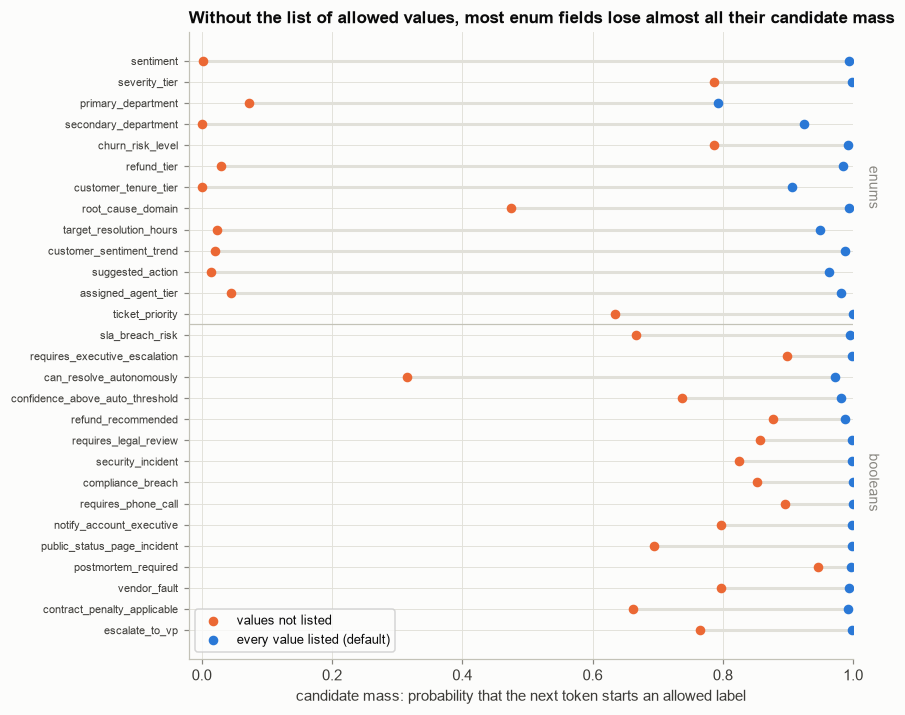

median candidate mass, enums   : listed 0.984 | not listed 0.030
median candidate mass, booleans: listed 0.998 | not listed 0.798

enums that keep over 0.3 without the list, and how their rows end:
  severity_tier          0.79  row ends erity_tier":·"SEV_  labels ['SEV_0_CRITICAL', 'SEV_1_MAJOR', 'SEV_2_MODERATE', 'SEV_3_MINOR']
  churn_risk_level       0.79  row ends urn_risk_level":·"  labels ['LOW', 'MEDIUM', 'HIGH', 'CRITICAL_IMMINENT']
  root_cause_domain      0.47  row ends t_cause_domain":·"  labels ['DNS_ROUTING', 'DB_LOCKING', 'API_GATEWAY', 'BILLING_SYNC', 'AUTH_TOKEN_EXPIRY']
  ticket_priority        0.63  row ends cket_priority":·"P  labels ['P0_EMERGENCY', 'P1_HIGH', 'P2_NORMAL', 'P3_LOW']


In [18]:
S = Schema.coerce(triage)
order = [f.name for f in S if f.type == "enum"] + [f.name for f in S if f.type == "boolean"]
m_list = np.array([listed_out.fields[n].candidate_mass for n in order])
m_bare = np.array([bare_out.fields[n].candidate_mass for n in order])
n_enum = sum(f.type == "enum" for f in S)

fig, ax = plt.subplots(figsize=(8.2, 6.6))
y = np.arange(len(order))
ax.hlines(y, m_bare, m_list, color=GRID, linewidth=2, zorder=1)
ax.scatter(m_bare, y, color=SERIES[1], s=28, zorder=2, label="values not listed")
ax.scatter(m_list, y, color=SERIES[0], s=28, zorder=3, label="every value listed (default)")
ax.axhline(n_enum - 0.5, color=BASELINE, linewidth=0.8)
ax.text(1.02, (n_enum - 1) / 2, "enums", rotation=270, va="center", color=MUTED, fontsize=9, transform=ax.get_yaxis_transform())
ax.text(1.02, n_enum + (len(order) - n_enum - 1) / 2, "booleans", rotation=270, va="center", color=MUTED, fontsize=9,
        transform=ax.get_yaxis_transform())
ax.set_yticks(y, order, fontsize=7.5)
ax.invert_yaxis()
ax.set_xlim(-0.02, 1.0)
ax.set_xlabel("candidate mass: probability that the next token starts an allowed label")
ax.set_title("Without the list of allowed values, most enum fields lose almost all their candidate mass")
ax.legend(loc="lower left", fontsize=8.5, frameon=True, facecolor=SURFACE)
plt.tight_layout(); plt.show()

for kind, sl in [("enums", slice(0, n_enum)), ("booleans", slice(n_enum, None))]:
    print(f"median candidate mass, {kind:8}: listed {np.median(m_list[sl]):.3f} | not listed {np.median(m_bare[sl]):.3f}")
cs_bare = bare.compile(triage)
print("\nenums that keep over 0.3 without the list, and how their rows end:")
for n in order[:n_enum]:
    if bare_out.fields[n].candidate_mass > 0.3:
        print(f"  {n:22} {bare_out.fields[n].candidate_mass:.2f}  row ends {vis(''.join(pieces(tok, cs_bare.fields[n].prefix))[-18:])}"
              f"  labels {list(Schema.coerce(triage)[n].choices)}")

Booleans survive without the list: `true` and `false` are the only natural ways to finish `"sla_breach_risk": ` in JSON, so even an uninformed model puts most of its mass there. Most enums collapse. Nothing in the prompt says the answer should be `"SECURITY_OPS"` rather than `"Security"`, so the model writes what it would write.

The enums that hold up are informative too. For `severity_tier` and `ticket_priority`, the row already contains the start of every label (`"SEV_`, `"P`), which shows the model the format. For `churn_risk_level` and `root_cause_domain`, the labels are close to the words the model would pick anyway. Neither helps a field like `customer_tenure_tier`.

What does it want to write instead? We score the full vocabulary at the decision position of a few fields, reproducing the engine's prefix exactly (prompt, plus the first field's answer line, which the engine writes before the other fields; post [06](06_engine_and_benchmarks.ipynb) explains why):

In [19]:
V = tok.vocab_size

def wanted(eng, out, name, k=4):
    """Top-k next tokens at the field's decision position, with the prefix the engine used."""
    c = eng.compile(triage)
    prefix = eng.backend.prefill(tok.encode(c.prompt.render(ticket.strip())))
    first = c.schema.names[0]
    if name != first:
        prefix = eng.backend.prefill(encode_after(tok, c.prompt.tail, c.answer_text({first: out.values[first]})), parent=prefix)
    cf = c.fields[name]
    lp = eng.backend.score(prefix, [cf.prefix], [Query(0, len(cf.prefix) - 1, tuple(range(V)))])[0]
    allowed = {v.seq[0] for v in cf.variants}
    return ", ".join(f"`{vis(tok.decode([int(t)]))}`{'' if int(t) in allowed else '✗'} {np.exp(lp[t]):.2f}"
                     for t in np.argsort(-lp)[:k])

rows = []
for name in ["sentiment", "secondary_department", "refund_tier", "customer_tenure_tier"]:
    for label, eng, out in [("not listed", bare, bare_out), ("listed", engine, listed_out)]:
        f = out.fields[name]
        rows.append([name if label == "not listed" else "", label, wanted(eng, out, name),
                     f"`{f.value}`", f"{f.probability:.2f}", f"{f.candidate_mass:.3f}"])
md_table(["field", "values", "model's top next tokens (✗ = starts no allowed label)", "decision", "probability", "candidate mass"], rows)

| field | values | model's top next tokens (✗ = starts no allowed label) | decision | probability | candidate mass |
|---|---|---|---|---|---|
| sentiment | not listed | `Negative`✗ 0.38, `negative`✗ 0.19, `An`✗ 0.09, `Critical`✗ 0.07 | `NEGATIVE` | 0.98 | 0.001 |
|  | listed | `NEG` 0.40, `VERY` 0.38, `POS` 0.20, `NE` 0.02 | `NEGATIVE` | 0.40 | 0.994 |
| secondary_department | not listed | `Legal`✗ 0.11, `Billing`✗ 0.09, `Customer`✗ 0.07, `billing`✗ 0.06 | `NETWORK_OPS` | 0.80 | 0.001 |
|  | listed | `NONE` 0.69, `IDENT` 0.16, `BILL`✗ 0.04, `DATABASE` 0.03 | `NONE` | 0.75 | 0.925 |
| refund_tier | not listed | `HIGH`✗ 0.09, `S`✗ 0.07, `REF`✗ 0.06, `L`✗ 0.05 | `FULL_MONTH_CREDIT` | 0.83 | 0.030 |
|  | listed | `NONE` 0.52, `FULL` 0.21, `PART` 0.18, `CUSTOM` 0.07 | `NONE` | 0.53 | 0.984 |
| customer_tenure_tier | not listed | `STR`✗ 0.96, `ST`✗ 0.01, `PRO`✗ 0.00, `Str`✗ 0.00 | `GROWTH` | 0.41 | 0.000 |
|  | listed | `EAR` 0.41, `ENTER` 0.33, `G` 0.12, `STR`✗ 0.06 | `EARLY_STAGE` | 0.45 | 0.906 |

Read the rows in pairs.

- Without the list, the model wants to write `Negative` or `negative` for `sentiment`. The right idea, in a spelling the schema doesn't allow. The decoder still returns `NEGATIVE` with a renormalized probability near 1, computed from a thousandth of the model's belief. The probability looks confident and means nothing; only the candidate mass gives it away.
- For `secondary_department` and `refund_tier`, the model's favorite tokens are department names and words of its own. The decisions without the list come from those slivers of mass, and they are different decisions.
- For `customer_tenure_tier`, the model wants to copy `STRATEGIC_TIER_1` straight from the ticket's `Account Priority` line. With the list, it chooses among the four allowed tiers instead, while still leaving some mass on the ticket's own label (`STR`). It then prefers `EARLY_STAGE` to `ENTERPRISE_STRATEGIC` by a small margin for a "Tier 1 Strategic Enterprise" customer, which is the model's judgment, not the prompt's: the list makes the question well-posed, not the answer right.

Across the schema:

In [20]:
differ = [n for n in listed_out.values if listed_out.values[n] != bare_out.values[n]]
print(f"{len(differ)} of {len(listed_out.values)} decisions change when the values are not listed: {differ}")

8 of 28 decisions change when the values are not listed: ['severity_tier', 'secondary_department', 'refund_tier', 'customer_tenure_tier', 'target_resolution_hours', 'vendor_fault', 'suggested_action', 'ticket_priority']


So the list is not decoration: it is what makes the model's distribution at the decision position a distribution over *our* labels. The teardown of the original engine found that for most enum fields less than 2% of the probability landed on any candidate, for exactly this reason; listing the values is the fix.

What does it cost? The head grows by several hundred tokens, and every request pays for a longer prompt in the batched pass, where each row attends over the whole prompt. Prefill of the head is the big cost, and it is paid once (section 6). The warm path, median of three runs:

In [21]:
t_list, r_list = timed(lambda: engine.extract(ticket, triage), repeats=3)
t_bare, r_bare = timed(lambda: bare.extract(ticket, triage), repeats=3)
md_table(["values", "prompt tokens", "cached (head)", "prefilled per request", "decode ms", "total ms"],
         [[label, r.stats.prompt_tokens, r.stats.cached_tokens, r.stats.prompt_tokens - r.stats.cached_tokens,
           f"{r.stats.decode_ms:.0f}", f"{t:.0f}"] for label, r, t in [("listed", r_list, t_list), ("not listed", r_bare, t_bare)]])
print(f"listing every value: {r_list.stats.prompt_tokens / r_bare.stats.prompt_tokens:.1f}x the prompt, "
      f"{t_list / t_bare:.2f}x the warm request time")

| values | prompt tokens | cached (head) | prefilled per request | decode ms | total ms |
|---|---|---|---|---|---|
| listed | 1146 | 901 | 245 | 384 | 645 |
| not listed | 691 | 446 | 245 | 352 | 605 |

listing every value: 1.7x the prompt, 1.07x the warm request time


Both requests prefill the same number of new tokens, because only the context and the tail are new. The longer prompt shows up mostly in the decode step, where every row attends over the catalog, and the ratio printed above is the whole per-request price of the list. That is the trade we take.

## 6. The head is the part we can cache

The head is identical for every request with the same schema, so its KV state can be computed once and reused. That only works if the head's tokens are a prefix of the full prompt's tokens: if the tokenizer merged the last characters of the head with the first characters of an input, the cached state would describe tokens the request doesn't contain. The engine checks this on every request:

In [22]:
show_source("engine.py", "n_head = len(cs.head_ids)", "prefix = self.backend.prefill(ids)")

# src/pcd/engine.py
140          n_head = len(cs.head_ids)
141          if n_head < len(ids) and tuple(ids[:n_head]) == cs.head_ids:
142              head, head_ms = self._head_prefix(cs)
143              stats.head_prefill_ms = head_ms
144              stats.cached_tokens = n_head if head_ms == 0.0 else 0
145              t = time.perf_counter()
146              prefix = self.backend.prefill(ids[n_head:], parent=head)
147          else:
148              warnings.append("the prompt head tokenizes differently with this context; prefix cache skipped")
149              prefix = self.backend.prefill(ids)


The head ends in a newline after `Input:`, a boundary that tokenizers rarely merge across. We tried some awkward first characters for the input on every tokenizer from section 4:

In [23]:
starts = ["Hello", '{"a": 1}', '"quoted"', "— dash", "<html>", "```log", "1234", "こんにちは", ":)"]
bad = []
for name, t in toks.items():
    c = compile_schema(small, t, fmt)
    for s in starts:
        if tuple(t.encode(c.prompt.render(s))[: len(c.head_ids)]) != c.head_ids:
            bad.append((name, s))
print(f"{len(toks) * len(starts) - len(bad)} of {len(toks) * len(starts)} (tokenizer, input) pairs keep the head as a token prefix; exceptions: {bad}")

54 of 54 (tokenizer, input) pairs keep the head as a token prefix; exceptions: []


If a pair ever does merge, the request still runs: the engine skips the cache for it, prefills the whole prompt, and says so in `warnings`.

Now the cache at work. A fresh engine, the schema compiled up front, then three requests: the triage ticket (cold), a different ticket, and the triage ticket again:

In [24]:
fresh = Engine(engine.backend)
fresh.compile(triage)
other = "The dashboard shows a 404 after login since this morning. Not urgent."
reqs = [("1: ticket, cold", fresh.extract(ticket, triage)), ("2: other input", fresh.extract(other, triage)),
        ("3: ticket, warm", fresh.extract(ticket, triage))]
md_table(["request", "prompt tokens", "cached tokens", "head prefill ms", "prefill ms", "forward passes", "total ms"],
         [[label, r.stats.prompt_tokens, r.stats.cached_tokens, f"{r.stats.head_prefill_ms:.0f}", f"{r.stats.prefill_ms:.0f}",
           r.stats.forward_passes, f"{r.stats.total_ms:.0f}"] for label, r in reqs])
cold, warm = reqs[0][1].stats, reqs[2][1].stats
print(f"same ticket, warm vs cold: {cold.total_ms / warm.total_ms:.1f}x faster; the cold request spent "
      f"{cold.head_prefill_ms / cold.total_ms:.0%} of its time prefilling the head")
print("same answers:", reqs[0][1].values == reqs[2][1].values)

| request | prompt tokens | cached tokens | head prefill ms | prefill ms | forward passes | total ms |
|---|---|---|---|---|---|---|
| 1: ticket, cold | 1146 | 0 | 887 | 271 | 5 | 1702 |
| 2: other input | 924 | 901 | 0 | 140 | 4 | 511 |
| 3: ticket, warm | 1146 | 901 | 0 | 261 | 4 | 645 |

same ticket, warm vs cold: 2.6x faster; the cold request spent 52% of its time prefilling the head
same answers: True


The first request pays for the head and one extra forward pass; every later request with the same schema starts from the cached state, whatever its input. The answers are identical, as they should be: the cached state is the same computation, done earlier. That is why the catalog's cost is a one-time cost. The engine keeps a small LRU of heads (`head_cache_size`, four by default), keyed by the head's token ids. Post [06](06_engine_and_benchmarks.ipynb) measures caching and the rest of the request in detail.

## What we learned

- A schema is a closed set of decisions. Three input formats normalize to the same fields and fingerprint, and free text is rejected before any model runs. `depends_on` groups fields into waves.
- The prompt comes from the model's own chat template, rendered once with a marker for the input and split into a cached head, the per-request context, and a tail that already opens the JSON object.
- Templates differ in ways that change answers: Gemma 2 needs the system text merged into the user turn, Qwen3 needs thinking switched off (with it on, five of 28 decisions changed while candidate mass looked fine), Llama 3.2 writes the date into the head.
- Listing every allowed value is what keeps the model's probability on our labels. Without it, most enum fields keep almost no candidate mass, and the renormalized probabilities look confident while meaning nothing.
- The list doubles the head, but the head is prefilled once per schema and reused, so what each request pays for it is mostly the decode step's attention over a longer prompt.

Next: [03 · Tokens are not characters](03_compiling_for_the_tokenizer.ipynb)